In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Data science environment ready.")

Data science environment ready.


In [2]:
import os

os.listdir("/content")

['.config', 'Sample - Superstore.xls', 'sample_data']

In [3]:
file_path = "/content/Sample - Superstore.xls"

excel_file = pd.ExcelFile(file_path)

print(excel_file.sheet_names)

['Orders', 'People', 'Returns']


In [4]:
df = pd.read_excel(
    file_path,
    sheet_name="Orders"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Retail Sales Data Cleaning & Quality Assessment

## Project Objective

The purpose of this analysis is to evaluate the quality and structure of historical retail transaction data and prepare a clean, reliable dataset for exploratory analysis, SQL analysis, statistical evaluation, and business intelligence reporting.

## 1. Initial Data Inspection

Before performing any transformations, the dataset will be evaluated for its dimensions, column structure, data types, missing values, duplicate records, and potential data-quality issues.

In [6]:
print("Dataset dimensions:", df.shape)

Dataset dimensions: (9994, 21)


In [7]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

## 2. Missing Value Assessment

Missing values are evaluated to determine whether incomplete records could affect the reliability of subsequent analysis. The number and percentage of missing observations are calculated for each variable.

In [9]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values[missing_values["Missing Count"] > 0]

,Missing Count,Missing Percentage
Postal Code,11,0.11


## 3. Duplicate Record Assessment

Duplicate observations can distort aggregate statistics and analytical results. The dataset is therefore evaluated for completely duplicated rows before additional transformations are performed.

In [10]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [12]:
print("Total rows:", len(df))
print("Unique Row IDs:", df["Row ID"].nunique())
print("Unique Order IDs:", df["Order ID"].nunique())
print("Unique Customers:", df["Customer ID"].nunique())
print("Unique Products:", df["Product ID"].nunique())

Total rows: 9994
Unique Row IDs: 9994
Unique Order IDs: 5009
Unique Customers: 793
Unique Products: 1862


## 4. Date Validation

Order and shipping dates are evaluated to confirm chronological consistency and identify potentially invalid records, including transactions where the shipping date occurs before the order date.

In [13]:
print("Earliest order:", df["Order Date"].min())
print("Latest order:", df["Order Date"].max())

print("Earliest shipment:", df["Ship Date"].min())
print("Latest shipment:", df["Ship Date"].max())

invalid_shipping = df[df["Ship Date"] < df["Order Date"]]

print("Ship dates before order dates:", len(invalid_shipping))

Earliest order: 2018-01-03 00:00:00
Latest order: 2021-12-30 00:00:00
Earliest shipment: 2018-01-07 00:00:00
Latest shipment: 2022-01-05 00:00:00
Ship dates before order dates: 0


In [14]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe().round(2)

,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


In [15]:
print("Negative sales:", (df["Sales"] < 0).sum())
print("Zero sales:", (df["Sales"] == 0).sum())

print("Non-positive quantities:", (df["Quantity"] <= 0).sum())

print("Discounts below 0:", (df["Discount"] < 0).sum())
print("Discounts above 1:", (df["Discount"] > 1).sum())

print("Negative-profit transactions:", (df["Profit"] < 0).sum())

Negative sales: 0
Zero sales: 0
Non-positive quantities: 0
Discounts below 0: 0
Discounts above 1: 0
Negative-profit transactions: 1871


## 5. Investigation of Missing Postal Codes

The dataset contains a small number of missing postal code values. Rather than automatically deleting or imputing these records, the affected observations are examined to determine whether the missing values follow a consistent geographic pattern.

In [16]:
df.loc[
    df["Postal Code"].isna(),
    ["City", "State", "Region", "Postal Code"]
].drop_duplicates()

,City,State,Region,Postal Code
2234,Burlington,Vermont,East,NaN


## 6. Profitability Assessment

Negative-profit transactions are retained because they may represent legitimate business outcomes rather than data-quality errors. Their frequency and relationship with discounting, product categories, and other business characteristics will be evaluated during exploratory analysis.

In [17]:
loss_rate = (df["Profit"] < 0).mean() * 100

print(f"Negative-profit transaction rate: {loss_rate:.2f}%")

Negative-profit transaction rate: 18.72%


In [18]:
df.groupby("Discount")["Profit"].agg(
    Transactions="count",
    Average_Profit="mean",
    Median_Profit="median"
).round(2)

,Transactions,Average_Profit,Median_Profit
Discount,,,
0.00,4798,66.90,16.00
0.10,94,96.06,54.32
0.15,52,27.29,14.10
0.20,3657,24.70,6.49
0.30,227,-45.68,-25.38
0.32,27,-88.56,-46.98
0.40,206,-111.93,-57.62
0.45,11,-226.65,-167.32
0.50,66,-310.70,-185.28


In [19]:
df.nsmallest(10, "Profit")[
    ["Product Name", "Category", "Sub-Category",
     "Sales", "Quantity", "Discount", "Profit"]
]

,Product Name,Category,Sub-Category,Sales,Quantity,Discount,Profit
7772,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,4499.985,5,0.7,-6599.9780
683,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.980,4,0.5,-3839.9904
9774,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,2177.584,8,0.8,-3701.8928
3011,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,2549.985,5,0.7,-3399.9800
4991,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,1889.990,5,0.8,-2929.4845
3151,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,1799.994,2,0.7,-2639.9912
5310,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,1525.188,6,0.8,-2287.7820
9639,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,4297.644,13,0.4,-1862.3124
1199,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,1088.792,4,0.8,-1850.9464
2697,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,6,0.5,-1811.0784


In [20]:
df.nlargest(10, "Profit")[
    ["Product Name", "Category", "Sub-Category",
     "Sales", "Quantity", "Discount", "Profit"]
]

,Product Name,Category,Sub-Category,Sales,Quantity,Discount,Profit
6826,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,17499.950,5,0.0,8399.9760
8153,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,13999.960,4,0.0,6719.9808
4190,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,10499.970,3,0.0,5039.9856
9039,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,9892.740,13,0.0,4946.3700
4098,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,9449.950,5,0.0,4630.4755
2623,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,11199.968,4,0.2,3919.9888
509,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,6354.950,5,0.0,3177.4750
8488,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,8749.950,5,0.0,2799.9840
7666,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,5399.910,9,0.0,2591.9568
6520,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,5443.960,4,0.0,2504.2216


In [22]:
sales_skewness = df["Sales"].skew()
profit_skewness = df["Profit"].skew()

print(f"Sales skewness: {sales_skewness:.2f}")
print(f"Profit skewness: {profit_skewness:.2f}")

Sales skewness: 12.97
Profit skewness: 7.56


In [23]:
print("Duplicate rows:", df.duplicated().sum())
print(
    "Ship dates before order dates:",
    (df["Ship Date"] < df["Order Date"]).sum()
)

Duplicate rows: 0
Ship dates before order dates: 0


### Preliminary Finding: Discounting and Profitability

The initial profitability assessment indicates a meaningful relationship between discount level and transaction profitability. Transactions with discounts between 0% and 20% maintain positive average and median profits. Beginning at a 30% discount, both average and median profitability become negative across all observed discount levels.

This pattern suggests that higher discount levels may represent a significant profitability risk. However, the relationship should not yet be interpreted as causal because profitability may also be influenced by product category, sub-category, region, quantity, and other transaction characteristics. Additional multivariate analysis will be conducted to determine whether the relationship persists across these business dimensions.

In [25]:
high_discount = df["Discount"] >= 0.30

high_discount_summary = pd.DataFrame({
    "Metric": [
        "Transactions",
        "Average Profit",
        "Median Profit",
        "Total Profit",
        "Loss-Making Transactions",
        "Loss Rate (%)"
    ],
    "Value": [
        high_discount.sum(),
        df.loc[high_discount, "Profit"].mean(),
        df.loc[high_discount, "Profit"].median(),
        df.loc[high_discount, "Profit"].sum(),
        (df.loc[high_discount, "Profit"] < 0).sum(),
        (df.loc[high_discount, "Profit"] < 0).mean() * 100
    ]
})

high_discount_summary

,Metric,Value
0,Transactions,1393.000000
1,Average Profit,-97.183098
2,Median Profit,-18.252500
3,Total Profit,-135376.056000
4,Loss-Making Transactions,1348.000000
5,Loss Rate (%),96.769562


In [26]:
df["Discount Group"] = np.where(
    df["Discount"] >= 0.30,
    "30% or Higher",
    "Below 30%"
)

discount_comparison = df.groupby("Discount Group").agg(
    Transactions=("Profit", "count"),
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Profit=("Profit", "mean")
).round(2)

discount_comparison["Profit_Margin_%"] = (
    discount_comparison["Total_Profit"] /
    discount_comparison["Total_Sales"] * 100
).round(2)

discount_comparison

,Transactions,Total_Sales,Total_Profit,Average_Profit,Profit_Margin_%
Discount Group,,,,,
30% or Higher,1393,362770.15,-135376.06,-97.18,-37.32
Below 30%,8601,1934430.71,421773.08,49.04,21.80


In [27]:
high_discount_by_category = (
    df[df["Discount"] >= 0.30]
    .groupby(["Category", "Sub-Category"])
    .agg(
        Transactions=("Profit", "count"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Average_Profit=("Profit", "mean")
    )
    .sort_values("Total_Profit")
    .round(2)
)

high_discount_by_category

,,Transactions,Total_Sales,Total_Profit,Average_Profit
Category,Sub-Category,,,,
Office Supplies,Binders,613,36140.61,-38510.50,-62.82
Furniture,Tables,176,89956.54,-30698.22,-174.42
Technology,Machines,53,76839.11,-29555.35,-557.65
Furniture,Bookcases,70,28544.00,-11097.76,-158.54
Office Supplies,Appliances,67,3382.53,-8629.64,-128.80
Furniture,Chairs,158,70005.50,-6737.12,-42.64
Technology,Phones,109,34337.35,-6385.79,-58.59
Furniture,Furnishings,138,6644.70,-5944.66,-43.08
Technology,Copiers,9,16919.80,2182.98,242.55


### Key Finding: High Discounts Represent a Major Profitability Risk

The analysis identified a substantial profitability difference between transactions discounted below 30% and those discounted 30% or more.

Transactions with discounts below 30% generated approximately $1.93 million in sales and $421,773 in total profit, producing a 21.80% profit margin. In contrast, transactions discounted 30% or more generated approximately $362,770 in sales but resulted in a total loss of approximately $135,376 and a -37.32% profit margin.

Of the 1,393 transactions receiving discounts of 30% or greater, 1,348 were unprofitable, representing a 96.77% loss rate.

These findings indicate that aggressive discounting is strongly associated with profitability erosion within the dataset. However, the results should not be interpreted as evidence that discounting alone causes these losses. Product mix, category, region, quantity, and other business factors may also contribute to profitability outcomes.

In [28]:
subcategory_discount_analysis = (
    df[df["Discount"] >= 0.30]
    .groupby("Sub-Category")
    .agg(
        Transactions=("Profit", "count"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Average_Discount=("Discount", "mean"),
        Average_Profit=("Profit", "mean")
    )
    .sort_values("Total_Profit")
    .round(2)
)

subcategory_discount_analysis

,Transactions,Total_Sales,Total_Profit,Average_Discount,Average_Profit
Sub-Category,,,,,
Binders,613,36140.61,-38510.50,0.74,-62.82
Tables,176,89956.54,-30698.22,0.39,-174.42
Machines,53,76839.11,-29555.35,0.54,-557.65
Bookcases,70,28544.00,-11097.76,0.44,-158.54
Appliances,67,3382.53,-8629.64,0.80,-128.80
Chairs,158,70005.50,-6737.12,0.30,-42.64
Phones,109,34337.35,-6385.79,0.40,-58.59
Furnishings,138,6644.70,-5944.66,0.60,-43.08
Copiers,9,16919.80,2182.98,0.40,242.55


In [29]:
regional_discount_analysis = (
    df[df["Discount"] >= 0.30]
    .groupby("Region")
    .agg(
        Transactions=("Profit", "count"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Average_Discount=("Discount", "mean"),
        Average_Profit=("Profit", "mean")
    )
    .sort_values("Total_Profit")
    .round(2)
)

regional_discount_analysis

,Transactions,Total_Sales,Total_Profit,Average_Discount,Average_Profit
Region,,,,,
Central,643,129134.10,-52392.27,0.61,-81.48
East,461,145870.40,-42088.61,0.51,-91.30
South,171,70716.99,-24880.48,0.64,-145.50
West,118,17048.66,-16014.69,0.67,-135.72


In [30]:
state_discount_analysis = (
    df[df["Discount"] >= 0.30]
    .groupby("State")
    .agg(
        Transactions=("Profit", "count"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Average_Profit=("Profit", "mean")
    )
    .sort_values("Total_Profit")
    .round(2)
)

state_discount_analysis.head(10)

,Transactions,Total_Sales,Total_Profit,Average_Profit
State,,,,
Texas,415,91590.01,-33955.28,-81.82
Ohio,179,49480.73,-20227.22,-113.00
Illinois,228,37544.09,-18436.99,-80.86
Pennsylvania,233,73189.16,-16140.10,-69.27
North Carolina,48,24864.71,-11076.89,-230.77
Colorado,44,6863.31,-8147.54,-185.17
Florida,84,33749.41,-7229.85,-86.07
Tennessee,39,12102.87,-6573.74,-168.56
Arizona,50,7665.87,-5728.77,-114.58


## 7. Visualization of High-Discount Profitability

To identify which product groups contribute most strongly to profitability erosion, total profit for transactions discounted 30% or more is compared across product sub-categories.

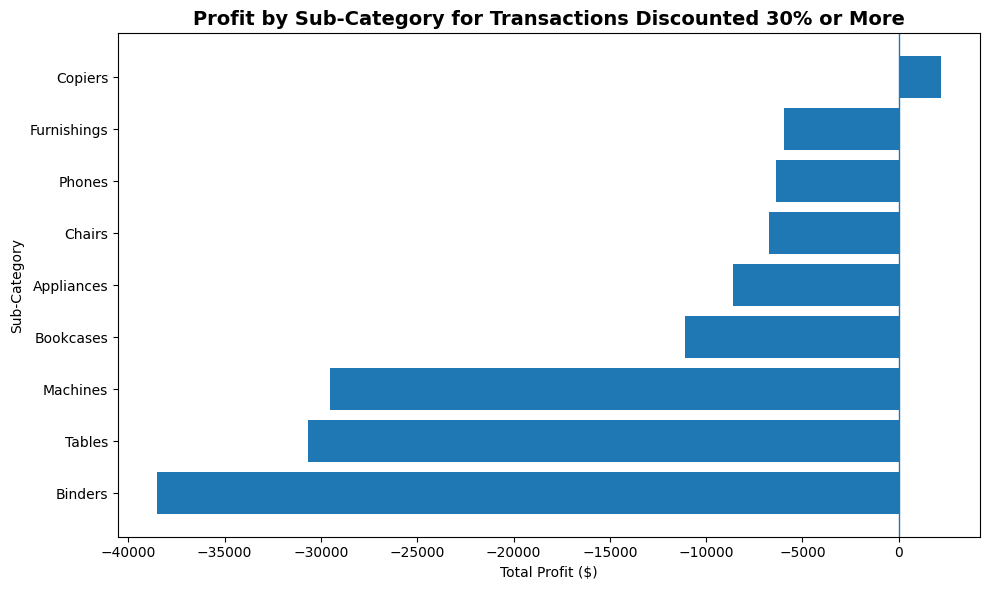

In [31]:
plot_data = subcategory_discount_analysis.sort_values("Total_Profit")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data.index,
    plot_data["Total_Profit"]
)

plt.axvline(0, linewidth=1)

plt.title(
    "Profit by Sub-Category for Transactions Discounted 30% or More",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total Profit ($)")
plt.ylabel("Sub-Category")

plt.tight_layout()
plt.show()

### Interpretation

High-discount profitability losses are concentrated in several product sub-categories rather than being distributed uniformly across the product portfolio. Binders generated the largest aggregate loss among transactions discounted 30% or more, followed by Tables and Machines.

Together, these three sub-categories generated approximately $98,764 in losses within the high-discount segment. In contrast, Copiers remained profitable despite discounts of 30% or greater, indicating that the financial effect of discounting varies by product type.

These findings suggest that management should evaluate discount policies at the product and sub-category level rather than applying a single organization-wide discount threshold.

In [32]:
discount_profit_correlation = df["Discount"].corr(df["Profit"])

print(
    f"Correlation between Discount and Profit: "
    f"{discount_profit_correlation:.3f}"
)

Correlation between Discount and Profit: -0.219


In [33]:
sales_profit_correlation = df["Sales"].corr(df["Profit"])

print(
    f"Correlation between Sales and Profit: "
    f"{sales_profit_correlation:.3f}"
)

Correlation between Sales and Profit: 0.479


In [34]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
overall_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_margin:.2f}%")
print(f"Total Transaction Lines: {len(df):,}")
print(f"Unique Orders: {df['Order ID'].nunique():,}")
print(f"Unique Customers: {df['Customer ID'].nunique():,}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.47%
Total Transaction Lines: 9,994
Unique Orders: 5,009
Unique Customers: 793


In [35]:
df["Discount Group"]

,Discount Group
0,Below 30%
1,Below 30%
2,Below 30%
3,30% or Higher
4,Below 30%
...,...
9989,Below 30%
9990,Below 30%
9991,Below 30%
9992,Below 30%


In [37]:
df["Postal Code"] = df["Postal Code"].astype("Int64")

## 8. Final Data Quality Validation

Following the initial quality assessment, the dataset was prepared for downstream analysis while preserving legitimate business observations.

Key cleaning decisions included:

- Retaining all transaction records because no invalid sales, quantity, or discount values were identified.
- Retaining negative-profit transactions because they represent legitimate business outcomes and are analytically important.
- Preserving the 11 missing postal code values rather than introducing an unverified geographic value.
- Converting Postal Code to a nullable integer data type because postal codes function as identifiers rather than continuous numerical measurements.
- Retaining the engineered Discount Group variable to support subsequent profitability analysis.
- Preserving extreme sales and profit observations pending further analytical evaluation rather than automatically treating them as data errors.

The processed dataset will serve as the standardized source for subsequent exploratory analysis, SQL analysis, visualization, and business intelligence reporting.

In [38]:
print("FINAL DATA QUALITY CHECK")
print("-" * 40)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Invalid sales values: {(df['Sales'] <= 0).sum()}")
print(f"Invalid quantity values: {(df['Quantity'] <= 0).sum()}")
print(f"Invalid discounts: {((df['Discount'] < 0) | (df['Discount'] > 1)).sum()}")
print(
    f"Invalid shipping dates: "
    f"{(df['Ship Date'] < df['Order Date']).sum()}"
)

FINAL DATA QUALITY CHECK
----------------------------------------
Rows: 9,994
Columns: 22
Duplicate rows: 0
Missing values: 11
Invalid sales values: 0
Invalid quantity values: 0
Invalid discounts: 0
Invalid shipping dates: 0


In [39]:
processed_file = "/content/sample_superstore_clean.csv"

df.to_csv(
    processed_file,
    index=False
)

print("Processed dataset exported successfully.")

Processed dataset exported successfully.


In [40]:
clean_check = pd.read_csv(processed_file)

print("Exported dimensions:", clean_check.shape)
clean_check.head()

Exported dimensions: (9994, 22)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Discount Group
0,1,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,Below 30%
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,Below 30%
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,Below 30%
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,30% or Higher
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,Below 30%


### Correlation Analysis

Pearson correlation analysis identified a negative relationship between discount and profit (r = -0.219), indicating that higher discount levels tend to be associated with lower transaction profitability. Sales and profit demonstrated a stronger positive relationship (r = 0.479), suggesting that higher-value transactions generally correspond with increased profit.

These relationships should be interpreted as associations rather than causal effects. Additional analysis of product category, geography, customer segment, and other transaction characteristics is necessary to better understand the factors influencing profitability.